In [70]:
import pandas as pd
import numpy as np

In [71]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shivan118/big-mart-sales-prediction-datasets")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'big-mart-sales-prediction-datasets' dataset.
Path to dataset files: /kaggle/input/big-mart-sales-prediction-datasets


In [72]:
import os
print(os.listdir(path))

data = pd.read_csv(os.path.join(path, 'train.csv'))
data.head()

['sample_submission.csv', 'train.csv', 'test.csv']


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


### Find Shape of Our Dataset (Number of Rows And Number of Columns)

In [73]:
data.shape

(8523, 12)

### Get Information About Our Dataset Like Total Number Rows, Total Number of Columns, Datatypes of Each Column And Memory Requirement

In [74]:
data.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


### Check Null Values In The Dataset

In [75]:
data.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [76]:
per = data.isnull().sum() * 100 / len(data)
print(per)

Item_Identifier               0.000000
Item_Weight                  17.165317
Item_Fat_Content              0.000000
Item_Visibility               0.000000
Item_Type                     0.000000
Item_MRP                      0.000000
Outlet_Identifier             0.000000
Outlet_Establishment_Year     0.000000
Outlet_Size                  28.276428
Outlet_Location_Type          0.000000
Outlet_Type                   0.000000
Item_Outlet_Sales             0.000000
dtype: float64


### Taking Care of Duplicate Values

In [77]:
data.duplicated().any()

np.False_

### Handling The missing Values

In [78]:
data['Item_Weight']

,Item_Weight
0,9.300
1,5.920
2,17.500
3,19.200
4,8.930
...,...
8518,6.865
8519,8.380
8520,10.600
8521,7.210


In [79]:
data['Outlet_Size']

,Outlet_Size
0,Medium
1,Medium
2,Medium
3,NaN
4,High
...,...
8518,High
8519,NaN
8520,Small
8521,Medium


### Univariate Imputation

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

In [81]:
mean_weight = data['Item_Weight'].mean()
median_weight = data['Item_Weight'].median()

In [82]:
print(mean_weight,median_weight)

12.857645184135976 12.6


In [83]:
data['Item_Weight_mean']=data['Item_Weight'].fillna(mean_weight)
data['Item_Weight_median']=data['Item_Weight'].fillna(median_weight)

In [84]:
data.head(1)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Weight_mean,Item_Weight_median
0,FDA15,9.3,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.138,9.3,9.3


In [85]:
print("Original Weight variable variance",data['Item_Weight'].var())
print("Item Weight variance after mean imputation",data['Item_Weight_mean'].var())
print("Item Weight variance after median imputation",data['Item_Weight_median'].var())

Original Weight variable variance 21.56168825983637
Item Weight variance after mean imputation 17.860121735060453
Item Weight variance after median imputation 17.869561454073366


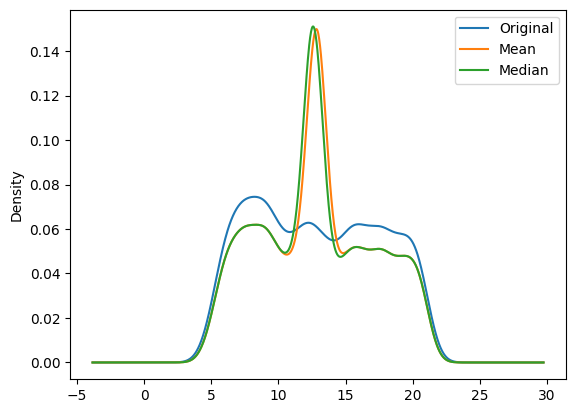

In [86]:
data['Item_Weight'].plot(kind = "kde",label="Original")

data['Item_Weight_mean'].plot(kind = "kde",label = "Mean")

data['Item_Weight_median'].plot(kind = "kde",label = "Median")

plt.legend()
plt.show()

<Axes: >

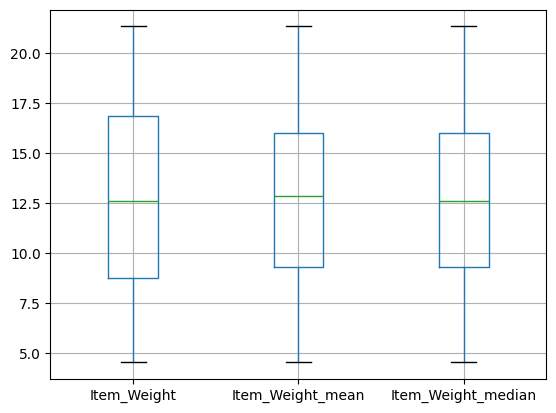

In [87]:
data[['Item_Weight','Item_Weight_mean','Item_Weight_median']].boxplot()

In [88]:
data['Item_Weight_interploate']=data['Item_Weight'].interpolate(method="linear")

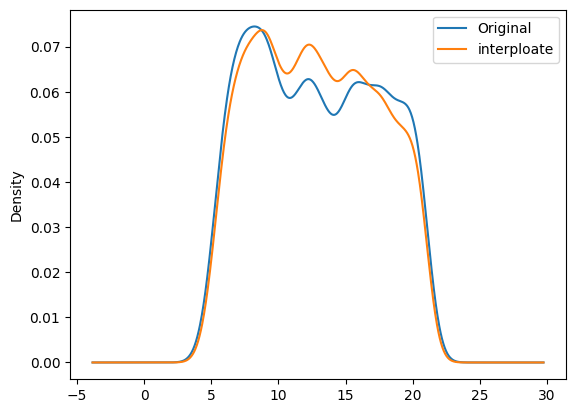

In [89]:
data['Item_Weight'].plot(kind = "kde",label="Original")

data['Item_Weight_interploate'].plot(kind = "kde",label = "interploate")

plt.legend()
plt.show()

### Multivariate Imputaion

In [90]:
from sklearn.impute import KNNImputer

In [91]:
knn = KNNImputer(n_neighbors=10,weights="distance")

In [92]:
data['knn_imputer']= knn.fit_transform(data[['Item_Weight']]).ravel()

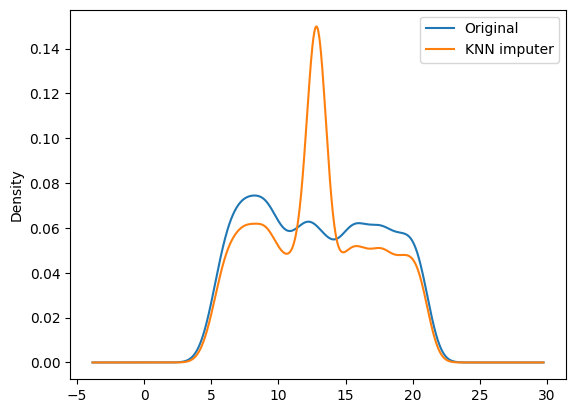

In [93]:
data['Item_Weight'].plot(kind = "kde",label="Original")

data['knn_imputer'].plot(kind = "kde",label = "KNN imputer")

plt.legend()
plt.show()

In [94]:
data = data.drop(['Item_Weight','Item_Weight_mean','Item_Weight_median','knn_imputer'],axis=1)

In [95]:
data.head(1)

,Item_Identifier,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Weight_interploate
0,FDA15,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.138,9.3


In [96]:
data.isnull().sum()

,0
Item_Identifier,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0
Outlet_Type,0


### Outlet_Size

In [97]:
data['Outlet_Size'].value_counts()

,count
Outlet_Size,
Medium,2793
Small,2388
High,932


In [98]:
data['Outlet_Type'].value_counts()

,count
Outlet_Type,
Supermarket Type1,5577
Grocery Store,1083
Supermarket Type3,935
Supermarket Type2,928


In [99]:
mode_outlet = data.pivot_table(values='Outlet_Size',columns='Outlet_Type',aggfunc=(lambda x:x.mode()[0]))

In [100]:
mode_outlet

Outlet_Type,Grocery Store,Supermarket Type1,Supermarket Type2,Supermarket Type3
Outlet_Size,Small,Small,Medium,Medium


In [101]:
missing_values = data['Outlet_Size'].isnull()

In [102]:
missing_values

,Outlet_Size
0,False
1,False
2,False
3,True
4,False
...,...
8518,False
8519,True
8520,False
8521,False


In [103]:
data.loc[missing_values,'Outlet_Size'] = data.loc[missing_values,'Outlet_Type'].apply(lambda x :mode_outlet[x])

In [104]:
data.isnull().sum()

,0
Item_Identifier,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0
Outlet_Type,0


### Item_Fat_Content

In [105]:
data.columns

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type',
       'Item_MRP', 'Outlet_Identifier', 'Outlet_Establishment_Year',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type',
       'Item_Outlet_Sales', 'Item_Weight_interploate'],
      dtype='object')

In [106]:
data['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


In [107]:
data.replace({'Item_Fat_Content':{'Low Fat':'LF','low fat':'LF','reg':'Regular'}},inplace=True)

In [108]:
data['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
LF,5517
Regular,3006


### Item_Visibility

In [109]:
data.columns

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type',
       'Item_MRP', 'Outlet_Identifier', 'Outlet_Establishment_Year',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type',
       'Item_Outlet_Sales', 'Item_Weight_interploate'],
      dtype='object')

In [110]:
data['Item_Visibility'].value_counts()

,count
Item_Visibility,
0.000000,526
0.076975,3
0.061271,2
0.046825,2
0.112399,2
...,...
0.054142,1
0.018920,1
0.044974,1


In [111]:
data['Item_Visibility_interpolate']=data['Item_Visibility'].replace(0,np.nan).interpolate(method='linear')

In [112]:
data.head(1)

,Item_Identifier,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Weight_interploate,Item_Visibility_interpolate
0,FDA15,LF,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.138,9.3,0.016047


In [113]:
data['Item_Visibility_interpolate'].value_counts()

,count
Item_Visibility_interpolate,
0.076975,3
0.128296,2
0.014041,2
0.052150,2
0.040912,2
...,...
0.046559,1
0.309390,1
0.039248,1


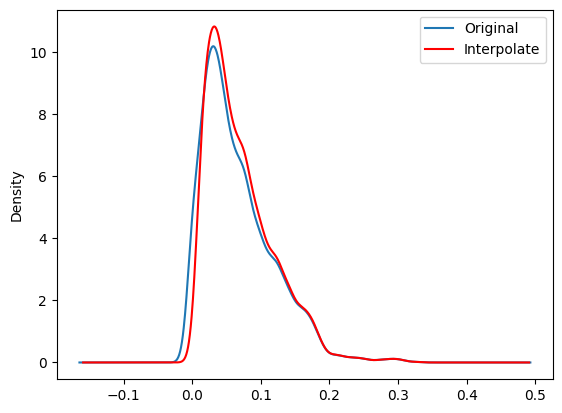

In [114]:
data['Item_Visibility'].plot(kind="kde",label="Original")

data['Item_Visibility_interpolate'].plot(kind="kde",color='red',label="Interpolate")

plt.legend()
plt.show()

In [115]:
data = data.drop('Item_Visibility',axis=1)

In [116]:
data.head(1)

,Item_Identifier,Item_Fat_Content,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Weight_interploate,Item_Visibility_interpolate
0,FDA15,LF,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.138,9.3,0.016047


### Item_Type

In [117]:
data.columns

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Item_MRP',
       'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size',
       'Outlet_Location_Type', 'Outlet_Type', 'Item_Outlet_Sales',
       'Item_Weight_interploate', 'Item_Visibility_interpolate'],
      dtype='object')

In [118]:
data['Item_Type'].value_counts()

,count
Item_Type,
Fruits and Vegetables,1232
Snack Foods,1200
Household,910
Frozen Foods,856
Dairy,682
Canned,649
Baking Goods,648
Health and Hygiene,520
Soft Drinks,445


### Item_Identifier

In [119]:
data.columns

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Item_MRP',
       'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size',
       'Outlet_Location_Type', 'Outlet_Type', 'Item_Outlet_Sales',
       'Item_Weight_interploate', 'Item_Visibility_interpolate'],
      dtype='object')

In [120]:
data['Item_Identifier'].value_counts().sample(5)

,count
Item_Identifier,
NCL54,3
FDW57,5
NCZ05,3
FDI38,5
NCN19,6


In [121]:
data['Item_Identifier'] =data['Item_Identifier'].apply(lambda x : x[:2])

In [122]:
data['Item_Identifier'].value_counts()

,count
Item_Identifier,
FD,6125
NC,1599
DR,799


### Outlet_Establishment_Year

In [123]:
data.columns

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Item_MRP',
       'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size',
       'Outlet_Location_Type', 'Outlet_Type', 'Item_Outlet_Sales',
       'Item_Weight_interploate', 'Item_Visibility_interpolate'],
      dtype='object')

In [124]:
data['Outlet_Establishment_Year']

,Outlet_Establishment_Year
0,1999
1,2009
2,1999
3,1998
4,1987
...,...
8518,1987
8519,2002
8520,2004
8521,2009


In [125]:
import datetime as dt

In [126]:
current_year = dt.datetime.today().year

In [127]:
current_year

2026

In [128]:
data['Outlet_age']= current_year - data['Outlet_Establishment_Year']

In [129]:
data.head(1)

,Item_Identifier,Item_Fat_Content,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Weight_interploate,Item_Visibility_interpolate,Outlet_age
0,FD,LF,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.138,9.3,0.016047,27


In [130]:
data = data.drop('Outlet_Establishment_Year',axis=1)

In [131]:
data.head()

,Item_Identifier,Item_Fat_Content,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Weight_interploate,Item_Visibility_interpolate,Outlet_age
0,FD,LF,Dairy,249.8092,OUT049,Medium,Tier 1,Supermarket Type1,3735.1380,9.30,0.016047,27
1,DR,Regular,Soft Drinks,48.2692,OUT018,Medium,Tier 3,Supermarket Type2,443.4228,5.92,0.019278,17
2,FD,LF,Meat,141.6180,OUT049,Medium,Tier 1,Supermarket Type1,2097.2700,17.50,0.016760,27
3,FD,Regular,Fruits and Vegetables,182.0950,OUT010,Small,Tier 3,Grocery Store,732.3800,19.20,0.015755,28
4,NC,LF,Household,53.8614,OUT013,High,Tier 3,Supermarket Type1,994.7052,8.93,0.014751,39


### Handling Categorical Columns

In [132]:
from sklearn.preprocessing import OrdinalEncoder

data_encoded = data.copy()

cat_cols = data.select_dtypes(include=['object']).columns

for col in cat_cols:
    oe = OrdinalEncoder()
    data_encoded[col]=oe.fit_transform(data_encoded[[col]])
    print(oe.categories_)

[array(['DR', 'FD', 'NC'], dtype=object)]
[array(['LF', 'Regular'], dtype=object)]
[array(['Baking Goods', 'Breads', 'Breakfast', 'Canned', 'Dairy',
       'Frozen Foods', 'Fruits and Vegetables', 'Hard Drinks',
       'Health and Hygiene', 'Household', 'Meat', 'Others', 'Seafood',
       'Snack Foods', 'Soft Drinks', 'Starchy Foods'], dtype=object)]
[array(['OUT010', 'OUT013', 'OUT017', 'OUT018', 'OUT019', 'OUT027',
       'OUT035', 'OUT045', 'OUT046', 'OUT049'], dtype=object)]
[array(['High', 'Medium', 'Small'], dtype=object)]
[array(['Tier 1', 'Tier 2', 'Tier 3'], dtype=object)]
[array(['Grocery Store', 'Supermarket Type1', 'Supermarket Type2',
       'Supermarket Type3'], dtype=object)]


In [133]:
data_encoded.head(3)

,Item_Identifier,Item_Fat_Content,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Weight_interploate,Item_Visibility_interpolate,Outlet_age
0,1.0,0.0,4.0,249.8092,9.0,1.0,0.0,1.0,3735.1380,9.30,0.016047,27
1,0.0,1.0,14.0,48.2692,3.0,1.0,2.0,2.0,443.4228,5.92,0.019278,17
2,1.0,0.0,10.0,141.6180,9.0,1.0,0.0,1.0,2097.2700,17.50,0.016760,27


In [134]:
X = data_encoded.drop('Item_Outlet_Sales',axis=1)
y = data_encoded['Item_Outlet_Sales']

In [135]:
y

,Item_Outlet_Sales
0,3735.1380
1,443.4228
2,2097.2700
3,732.3800
4,994.7052
...,...
8518,2778.3834
8519,549.2850
8520,1193.1136
8521,1845.5976


In [136]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score


linear_regressor = LinearRegression()


scores_lr = cross_val_score(linear_regressor,X, y, cv=5, scoring='r2')
print(scores_lr.mean())

0.5015470931017388


In [69]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(n_estimators=100, random_state=42)
scores_gbr = cross_val_score(gbr, X, y, cv=5, scoring='r2')
print(scores_gbr.mean())

0.5946110912025315


### Random Forest Regressor

In [137]:
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100,random_state=42)
scores = cross_val_score(rf,X,y,cv=5,scoring='r2')
print(scores.mean())

0.55503516377978


### XGBRFRegressor

In [138]:
from xgboost import XGBRFRegressor

xg = XGBRFRegressor(n_estimators=100,random_state=42)
scores = cross_val_score(xg,X,y,cv=5,scoring='r2')
print(scores.mean())

0.5955270459526943


### XGBRFRegressor Feature importances

In [139]:
xg = XGBRFRegressor(n_estimators=100,random_state=42)

xg1 = xg.fit(X,y)
pd.DataFrame({
    'feature':X.columns,
    'XGBRF_importance':xg1.feature_importances_

}).sort_values(by='XGBRF_importance',ascending=False)

,feature,XGBRF_importance
7,Outlet_Type,0.428726
10,Outlet_age,0.154613
3,Item_MRP,0.143704
5,Outlet_Size,0.136857
4,Outlet_Identifier,0.118608
6,Outlet_Location_Type,0.008615
9,Item_Visibility_interpolate,0.002940
8,Item_Weight_interploate,0.002302
2,Item_Type,0.001865
0,Item_Identifier,0.001068


In [140]:
['Item_Visibility_interpolate','Item_Weight_interploate',
'Item_Type','Outlet_Location_Type','Item_Identifier','Item_Fat_Content']

['Item_Visibility_interpolate',
 'Item_Weight_interploate',
 'Item_Type',
 'Outlet_Location_Type',
 'Item_Identifier',
 'Item_Fat_Content']

In [141]:
from xgboost import XGBRFRegressor

xg = XGBRFRegressor(n_estimators=100,random_state=42)
scores = cross_val_score(xg1,X.drop(['Item_Visibility_interpolate','Item_Weight_interploate',
'Item_Type','Outlet_Location_Type','Item_Identifier','Item_Fat_Content'],axis=1),y,cv=5,scoring='r2')
print(scores.mean())

0.5961723971108985


In [142]:
final_data = X.drop(columns=['Item_Visibility_interpolate','Item_Weight_interploate',
'Item_Type','Outlet_Location_Type','Item_Identifier','Item_Fat_Content'],axis=1)

In [143]:
final_data

,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Type,Outlet_age
0,249.8092,9.0,1.0,1.0,27
1,48.2692,3.0,1.0,2.0,17
2,141.6180,9.0,1.0,1.0,27
3,182.0950,0.0,2.0,0.0,28
4,53.8614,1.0,0.0,1.0,39
...,...,...,...,...,...
8518,214.5218,1.0,0.0,1.0,39
8519,108.1570,7.0,2.0,1.0,24
8520,85.1224,6.0,2.0,1.0,22
8521,103.1332,3.0,1.0,2.0,17


### Best Model

In [144]:
from xgboost import XGBRFRegressor

In [145]:
xg_final = XGBRFRegressor()

In [146]:
xg_final.fit(final_data,y)

XGBRFRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bytree=None, device=None,
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric=None, feature_types=None, feature_weights=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None,
               num_parallel_tree=None, objective='reg:squarederror',
               random_state=None, ...)

In [147]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

In [148]:
X_train,X_test,y_train,y_test = train_test_split(final_data,y,
                                                 test_size=0.20,
                                                 random_state=42)

In [149]:
xg_final.fit(X_train,y_train)

XGBRFRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bytree=None, device=None,
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric=None, feature_types=None, feature_weights=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None,
               num_parallel_tree=None, objective='reg:squarederror',
               random_state=None, ...)

In [150]:
y_pred = xg_final.predict(X_test)

In [151]:
mean_absolute_error(y_test,y_pred)

714.5479888800818

### Prediction on Unseen Data

In [152]:
pred = xg_final.predict(np.array([[141.6180,9.0,1.0,1.0,24]]))[0]
print(pred)

2049.1736


In [153]:
print(f"Sales Value is between {pred-714.42} and {pred+714.42}")

Sales Value is between 1334.753662109375 and 2763.593505859375


In [154]:
for col in cat_cols:
    oe = OrdinalEncoder()
    data_encoded[col] = oe.fit_transform(data_encoded[[col]])
    print(col, "→", oe.categories_)

Item_Identifier → [array([0., 1., 2.])]
Item_Fat_Content → [array([0., 1.])]
Item_Type → [array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15.])]
Outlet_Identifier → [array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.])]
Outlet_Size → [array([0., 1., 2.])]
Outlet_Location_Type → [array([0., 1., 2.])]
Outlet_Type → [array([0., 1., 2., 3.])]


In [155]:
#for app.py
OUTLET_ID_MAP   = {'OUT010': 0, 'OUT013': 1, 'OUT017': 2, 'OUT018': 3, 'OUT019': 4, 'OUT027': 5, 'OUT035': 6, 'OUT045': 7, 'OUT046': 8, 'OUT049': 9}
OUTLET_SIZE_MAP = {'High': 0, 'Medium': 1, 'Small': 2}
OUTLET_TYPE_MAP = {'Grocery Store': 0, 'Supermarket Type1': 1, 'Supermarket Type2': 2, 'Supermarket Type3': 3}

### Save Model Using Joblib

In [156]:
import joblib

In [157]:
joblib.dump(xg_final,'bigmart_model')

['bigmart_model']

bigmart_explainer saved ✓


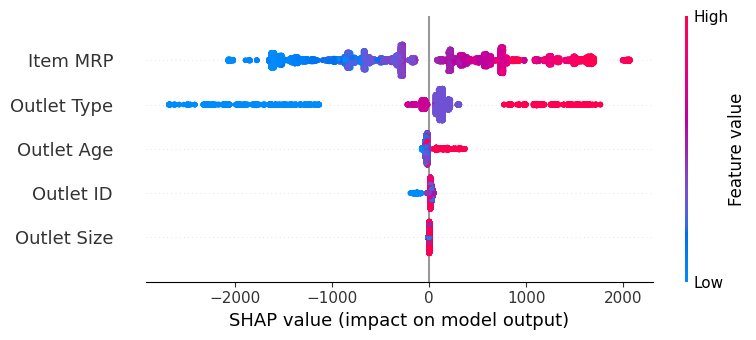

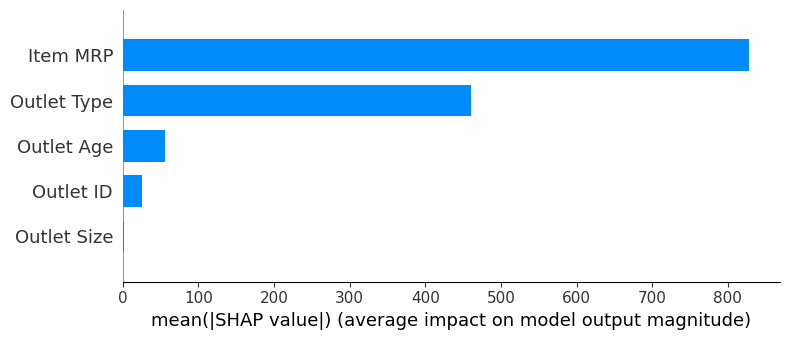

<Figure size 640x480 with 0 Axes>

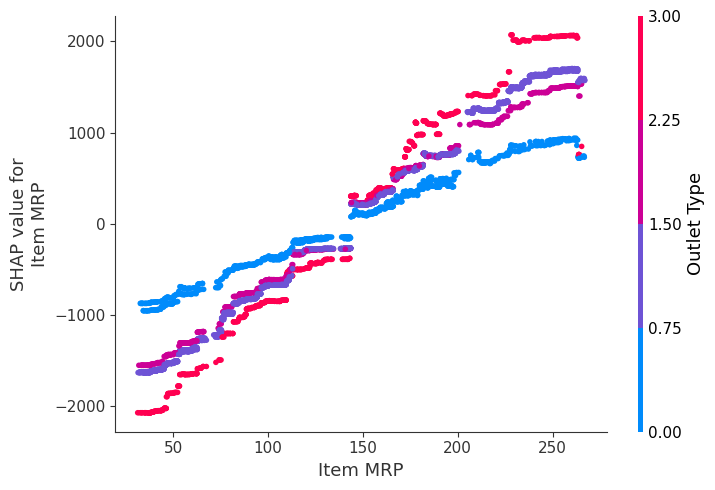

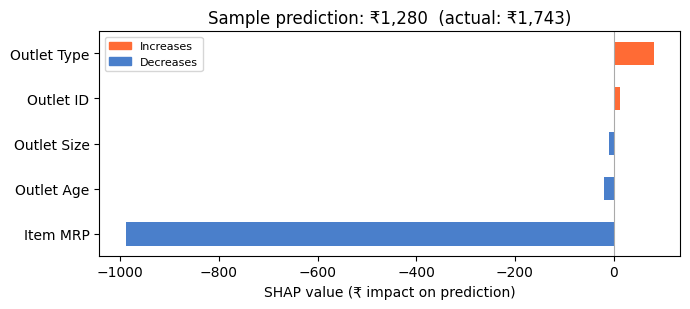

In [159]:
# ── Cell A: Install & import ──────────────────────────────────────────────────
# (shap is already in requirements.txt; this cell is just for local runs)
# !pip install shap --quiet

import shap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Cell B: Create & save the explainer ──────────────────────────────────────
#
# xg_final  → your trained XGBRFRegressor  (already defined above)
# final_data → the 5-column encoded DataFrame used for training
#
# TreeExplainer is the native, exact explainer for XGBoost — no approximation.

explainer = shap.TreeExplainer(xg_final)

# Compute SHAP values for the full training set (used for summary plots)
shap_values_train = explainer.shap_values(final_data)

# Save the explainer next to bigmart_model so app.py can load it
import joblib
joblib.dump(explainer, 'bigmart_explainer')
print("bigmart_explainer saved ✓")

# ── Cell C: Global summary plot (beeswarm) ────────────────────────────────────
# Shows how each feature affects predictions across all training samples.
# Red = high feature value pushes prediction up; blue = low value pulls it down.

plt.figure()
shap.summary_plot(
    shap_values_train,
    final_data,
    plot_type="dot",
    feature_names=["Item MRP", "Outlet ID", "Outlet Size", "Outlet Type", "Outlet Age"],
    show=False
)
plt.tight_layout()
plt.savefig("shap_summary_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Cell D: Bar plot (mean absolute SHAP — feature importance ranking) ────────
plt.figure()
shap.summary_plot(
    shap_values_train,
    final_data,
    plot_type="bar",
    feature_names=["Item MRP", "Outlet ID", "Outlet Size", "Outlet Type", "Outlet Age"],
    show=False
)
plt.tight_layout()
plt.savefig("shap_summary_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Cell E: Dependence plot for Item_MRP (your #1 feature) ───────────────────
# Shows how Item_MRP's SHAP value changes across its value range,
# coloured by a second interacting feature (auto-selected by SHAP).

plt.figure()
shap.dependence_plot(
    "Item MRP",
    shap_values_train,
    final_data,
    feature_names=["Item MRP", "Outlet ID", "Outlet Size", "Outlet Type", "Outlet Age"],
    show=False
)
plt.tight_layout()
plt.savefig("shap_dependence_mrp.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Cell F: Single-prediction waterfall (same logic as app.py) ───────────────
# Explain the first test-set prediction so you can verify the chart matches
# what the Streamlit app will show.

sample_idx    = 0
sample_input  = X_test.iloc[[sample_idx]]   # 1-row DataFrame
sample_sv     = explainer.shap_values(sample_input)[0]
feature_labels = ["Item MRP", "Outlet ID", "Outlet Size", "Outlet Type", "Outlet Age"]

order          = sample_sv.argsort()         # ascending absolute value

fig, ax = plt.subplots(figsize=(7, 3.2))
colors  = ['#ff6b35' if v > 0 else '#4a7fcb' for v in sample_sv[order]]
ax.barh([feature_labels[i] for i in order], sample_sv[order], color=colors, height=0.52)
ax.axvline(0, color='#aaaaaa', linewidth=0.8)
ax.set_xlabel("SHAP value (₹ impact on prediction)")
ax.set_title(
    f"Sample prediction: ₹{xg_final.predict(sample_input)[0]:,.0f}  "
    f"(actual: ₹{y_test.iloc[sample_idx]:,.0f})"
)
pos_p = mpatches.Patch(color='#ff6b35', label='Increases')
neg_p = mpatches.Patch(color='#4a7fcb', label='Decreases')
ax.legend(handles=[pos_p, neg_p], fontsize=8)
plt.tight_layout()
plt.savefig("shap_single_prediction.png", dpi=150, bbox_inches="tight")
plt.show()


In [160]:
model = joblib.load('bigmart_model')

In [161]:
pred = model.predict(np.array([[141.6180,9.0,1.0,1.0,24]]))[0]
print(pred)

2049.1736


In [162]:
print(f"Sales Value is between {pred-714.42} and {pred+714.42}")

Sales Value is between 1334.753662109375 and 2763.593505859375
